# Import Required Libraries
Import the necessary libraries, including the dataset loader from src/dataloaders/datasets/a_thaliana_dataset.py.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import TrainingArguments, Trainer, logging
import torch
from datasets import Dataset

# list of HyenaDNA pretrained models available in the hugging face hub
pretrained_models_max_length = {
    'hyenadna-tiny-1k-seqlen-hf': 1024,
        'hyenadna-small-32k-seqlen-hf': 32768,
        'hyenadna-medium-160k-seqlen-hf': 160000,
        'hyenadna-medium-450k-seqlen-hf': 450000,  # T4 up to here
        'hyenadna-large-1m-seqlen-hf': 1_000_000,
}
pretrained_model_name = 'hyenadna-small-32k-seqlen-hf'

# instantiate pretrained model
checkpoint = 'LongSafari/'+pretrained_model_name
tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)

/home/lpedraza/anaconda3/envs/hyena-dna/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lpedraza/anaconda3/envs/hyena-dna/lib/python3.8/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.


# Exploratory Data Analysis (EDA)
Load the dataset using the provided BED and FA files.

In [3]:
# Import the dataset loader
from src.dataloaders.datasets.a_thaliana_dataset import a_thalinana_Dataset

# Define the paths to the BED and FA files
bed_file_path = 'data/A.Thaliana/A.Thaliana.bed'
fa_file_path = 'data/A.Thaliana/TAIR10_mod.fna'

# Load the dataset using the provided BED and FA files
ds_test = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='test', 
                              max_length = 2000,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )

In [4]:
ds_test.label_dict

{'gene': 0, 'intergenic': 1}

In [5]:
data_test = []
labels_test = []
for _, (d, l) in enumerate(ds_test):
    data_test.append(d.tolist())
    labels_test.append(l.item())

In [6]:
len(data_test), len(labels_test)

(1234, 1234)

In [10]:
seq_0 = str.join('',tokenizer.convert_ids_to_tokens(data_test[0]))
print(seq_0)
print(len(seq_0))

AAAAGCTAACAACATTTGATGGGTCGGAAATAGGCGGCAGAATAACAACTGCCGCCAAAAAAATAAAAAAACGAAAATATATAATTACACATTTACACCAAAGTGTGATCTAAATTGAACGGTGCAGATTAGTTTAACATTTATCCCAAATTTTAAGAACCGTACGATGGAGCATCTTAATGACTTAAACCCTAAAAGAAGAAAAACCCCAATCGAGCTCTGTCAATGGCTCGCTTCGTCAGATGTCTGAGAAGAACACTCTTTTCTAATTCGTCTCCTTCTATTGCTCACCGGAGCCCTAGGATTGGTTTGCCCACGAATCTAAATCCTAAAATTTTAATCAGCCGCAGATGTCTGAGCTCCGGGAGTTACGTCTCAGAAATGCAGAAATCAGCTTTCCAGGGCAACATTTTGCGACTGATCCGTAATGAGATTGAGTACGAACTCGATCACTCGCCTCCTCTTCAGGTTCTCTATGAATCTCTTTTTTTTTGGTTCTATATTCTTTAAGCCTTCTAGGAATCTGGTTTTGGAATAGTGTTATTGATCAATTGATTGTTTTGGCATGAGAATCATATAAATGTTGATCTGTATAGTGTAACTTAGGTTGATACAATTTGTAAACTATTGGATGAAGAAAATGTTCACATCTCTGCAATGGCCTCTCTGTTTTGGGATTTGCAAGTTTTTTTTTTTTTTGGCAAGTTGCAGTGACCTCTTATAAACCCATACGTTAGCTAGTGACAACTTTCTAGTTCGTCTACAATGCATTTCCATGAACTTTTGCTTCCATTTCCGACATTTCTCCCACTGGCTACATTGAATAATACTTTGAGCACTTTTGCTTGTACAAATTTGCAGCCTCCTAACAGTTTTGGTCCATTCACTGTGGATGAACGGCCTGGAGAGCAGTGGATTAGCTTGAAAAGGAATTTTGGGGATAAAGAAGACATCAAAATTGAAGCAACTATGTTTGATAGATCAGTTCCCACGTCAAAAT

# Display Dataset Information
Display basic information about the dataset, such as the number of entries and a preview of the data.

In [11]:
# Display basic information about the dataset
# Number of entries in the dataset
num_entries = len(ds_test)
print(f"Number of entries in the dataset: {num_entries}")

Number of entries in the dataset: 1234


In [18]:
seq_0 = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(data_test[-1]))
print(seq_0)
print(len(seq_0))

GCTTAGAAGAGTCAACCAAAACCCCTGGCCCTTTCTAGAAGGGCCTGACATCAACGTTAACATGGTCTGACCTTACCTGTGGATTTCGATACCCAACATAGCTCCCTAGGCTCCTCAGCAGGGGTCACTGAGGATTAACTGTAAACACGGCGCCTCTATTATGGCCGCGCGATACCCGTACGAGATACTCGTGGGTACCCTTGAGACTTTGTTTAAAGCTGCTTTTTCATTAAGTTAACCAATGATTACAAATAGTTAAACGGATGTAGTTAATGCGGTATAAATAATATTTACTGTTGTAGCTTTGAATGGGTGAGTGGCGTGGCAGGGTTTGGTGCCCAATAAATTAATAAACACGTTTTGTTTCCATTCATCCAAAAAATGGGACCGTATATACAGTGGCATGTTCATTTTGGGTAACGAGCCGGGTAATGCGATAAGGGTCGGAAATATATAAAAAGTACTATCGAAACATACACGATAATTTATGAGATGAAACTTTCAGTTCATATATTGGGTTAGTTAGTTTCTATACGTAAAATCATTACCCTCACTCTTATTTTCAAATTTAGAAAATAAGTACTTGTGGAAATTTAAAAAAGATTCAAATTTACTAAATATGCGAGTAGGATTTTATTTTTTCCTATTGTTAATATATTTTTGCGCTATAATAAACGAAATTGTCCTAATTGTAGATAGTAAATTTAGCAAAGACCATTGCAGCAATGTGTGCAACCTTATGTAGAACTATTTAGTGATGCGGTAAGAAGATGACAATAAAAAGAGGTGTCAATAGTTGGTGGTACAAAACACAAACACTAGTGACAGAAAGAGTATTGTACTGCCATCATTTTGAAATTTCAATATTAATTTTTCTAATTAAACTCTTTCAAGTGAAACTAATAACCATGTGTTGCATGAAAATTCTTTTCAACGTCCGTTTTCGTTTCTAAAACGCAGGTATAAACTATTTTTTTTCCTTTATCCTTTAATTAAACTA

In [16]:
from Bio import SeqIO
from Bio.Seq import Seq

def find_sequence_in_fasta(fasta_file, query_sequence):
    seq_len = len(query_sequence)
    # Cargar el archivo FASTA
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequence = str(record.seq)
        sequence = sequence.upper() # Convertir a mayúsculas
        reverse_complement_seq = str(record.seq.reverse_complement())
        chr_len = len(sequence)

        # Buscar la secuencia directa
        if query_sequence in sequence:
            start = sequence.find(query_sequence)
            end = start + seq_len
            print(f"Secuencia encontrada en {record.id} (strand +) en la posición: {start}")
            print(f"{record.id}, seq in strand +: {sequence[start: end]}")
            return (record.id, start, end, '+')

        # Buscar el reverse complement
        if query_sequence in reverse_complement_seq:
            end = chr_len - reverse_complement_seq.find(query_sequence)
            start = end - seq_len
            print(f"Secuencia encontrada en {record.id} (strand -) en la posición: {start} del strand +")
            print(f"{record.id}, seq in strand +: {reverse_complement_seq[start: end]}")
            return (record.id, start, end, '-')

    print("Secuencia no encontrada en el archivo FASTA.")
    return None

In [19]:
# Buscar la secuencia
result = find_sequence_in_fasta(fasta_file=fa_file_path, query_sequence=seq_0)
if result:
    chr, start, end, strand = result
    print(f"Coordenadas: chr={chr}, start={start}, end={end}, strand={strand}")

Secuencia no encontrada en el archivo FASTA.


In [44]:
# carga el archivo A_Thaliana.bed en un dataframe
df = pd.read_csv(bed_file_path, sep='\t', header=None)
df.columns = ['chr', 'start', 'end', 'label', 'split', 'strand']
df.head()

,chr,start,end,label,split,strand
0,chr1,50000,50100,gene,2,-
1,chr2,519826,525528,intergenic,0,.
2,chr1,756262,757300,intergenic,2,-
3,chr4,759357,768230,intergenic,2,.
4,chr5,723043,723288,gene,1,+


In [ ]:
from BCBio import GFF

def gff_to_bed(gff_file, bed_file):
    with open(gff_file) as gff_handle, open(bed_file, 'w') as bed_handle:
        for rec in GFF.parse(gff_handle):
            for feature in rec.features:
                if feature.type == "gene":
                    chrom = rec.id
                    start = feature.location.start
                    end = feature.location.end
                    name = feature.qualifiers.get("Name", [""])[0]
                    score = 0
                    strand = feature.strand
                    bed_handle.write(f"{chrom}\t{start}\t{end}\t{name}\t{score}\t{strand}\n")

# Uso de la función
gff_file = "path/to/your_file.gff"
bed_file = "path/to/your_file.bed"
gff_to_bed(gff_file, bed_file)

## Train HyenaDNA with gene-intergen dataset

In [2]:
model  = AutoModelForSequenceClassification.from_pretrained(checkpoint, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Some weights of the model checkpoint at LongSafari/hyenadna-small-32k-seqlen-hf were not used when initializing HyenaDNAForSequenceClassification: ['lm_head.weight']
- This IS expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of H

### Data loading

In [3]:
# Experiment settings:

# Define the paths to the BED and FA files
bed_file_path = 'data/A.Thaliana/A.Thaliana.bed'
fa_file_path = 'data/A.Thaliana/TAIR10_mod.fna'
# Other dataset settings
use_padding = True
rc_aug = True  # reverse complement augmentation
add_eos = False  # add end of sentence token
# Training settings
num_epochs = 30  # ~100 seems fine
max_length = 2000  # max len of sequence of dataset (of what you want)
batch_size = 16 # ~256 was used
learning_rate = 6e-4  # good default for Hyena
weight_decay = 0.1

In [4]:
# Import the dataset loader
from src.dataloaders.datasets.a_thaliana_dataset import a_thalinana_Dataset

# Load the dataset using the provided BED and FA files
ds_test = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='test', 
                              max_length = 2000,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )
ds_val = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='val', 
                              max_length = 2000,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )
ds_train = a_thalinana_Dataset(bed_file=bed_file_path, 
                              fasta_file=fa_file_path, 
                              split='train', 
                              max_length = 2000,
                              tokenizer = tokenizer,
                              tokenizer_name='char',
                              replace_N_token = True
                              )

In [5]:
# load the dataset
# Dataset.from_dict expects input_ids as a nested list with size [batch, seq_len] 
# and labels as a list with size [batch]
data_train = []
labels_train = []
for _, (d, l) in enumerate(ds_train):
    data_train.append(d.tolist())
    labels_train.append(l.item())

DS_train = Dataset.from_dict({"input_ids": data_train, "labels": labels_train})
DS_train.set_format('pt')
# shuffle the dataset
DS_train = DS_train.shuffle(seed=42)

data_val = []
labels_val = []
for _, (d, l) in enumerate(ds_val):
    data_val.append(d.tolist())
    labels_val.append(l.item())

DS_val = Dataset.from_dict({"input_ids": data_val, "labels": labels_val})
DS_val.set_format('pt')
# shuffle the dataset
DS_val = DS_val.shuffle(seed=42)

data_test = []
labels_test = []
for _, (d, l) in enumerate(ds_test):
    data_test.append(d.tolist())
    labels_test.append(l.item())

DS_test = Dataset.from_dict({"input_ids": data_test, "labels": labels_test})
DS_test.set_format('pt')
# shuffle the dataset
DS_test = DS_test.shuffle(seed=42)


print(f"Train dataset shape:[{len(data_train)},{len(data_train[0])}]")
print(f"Train labels shape:[{len(labels_train)}]")  

print(f"Validation dataset shape:[{len(data_val)},{len(data_val[0])}]")
print(f"Validation labels shape:[{len(labels_val)}]")

print(f"Test dataset shape:[{len(data_test)},{len(data_test[0])}]")
print(f"Test labels shape:[{len(labels_test)}]")  

Train dataset shape:[9603,2000]
Train labels shape:[9603]
Validation dataset shape:[1163,2000]
Validation labels shape:[1163]
Test dataset shape:[1234,2000]
Test labels shape:[1234]


### Trianing

In [6]:
# filter out warnings
import warnings
warnings.filterwarnings("ignore")

# disable wandb
import os 
os.environ["WANDB_DISABLED"] = "true"

In [7]:
# Initialize Trainer
# Note that we're using extremely small batch sizes to maximize
# our ability to fit long sequences in memory!
args = {
    "output_dir": "tmp",
    "num_train_epochs": num_epochs,
    "per_device_train_batch_size": batch_size,
    "per_device_eval_batch_size": batch_size,
    "gradient_accumulation_steps": 4,
    # "gradient_checkpointing": True,
    "learning_rate": learning_rate,
}
training_args = TrainingArguments(**args)

trainer = Trainer(model=model, args=training_args, train_dataset=DS_train, eval_dataset=DS_val)
result = trainer.train()

print(result)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
***** Running training *****
  Num examples = 9603
  Num Epochs = 30
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 64
  Gradient Accumulation steps = 4
  Total optimization steps = 4500
  Number of trainable parameters = 3278080
 11%|█         | 500/4500 [07:33<1:00:21,  1.10it/s]Saving model checkpoint to tmp/checkpoint-500
Configuration saved in tmp/checkpoint-500/config.json
Model weights saved in tmp/checkpoint-500/pytorch_model.bin


{'loss': 0.1888, 'learning_rate': 0.0005333333333333333, 'epoch': 3.33}


 22%|██▏       | 1000/4500 [15:07<52:51,  1.10it/s] Saving model checkpoint to tmp/checkpoint-1000
Configuration saved in tmp/checkpoint-1000/config.json
Model weights saved in tmp/checkpoint-1000/pytorch_model.bin


{'loss': 0.1316, 'learning_rate': 0.0004666666666666666, 'epoch': 6.67}


 33%|███▎      | 1500/4500 [22:40<45:22,  1.10it/s]Saving model checkpoint to tmp/checkpoint-1500
Configuration saved in tmp/checkpoint-1500/config.json
Model weights saved in tmp/checkpoint-1500/pytorch_model.bin


...

{'loss': 0.0008, 'learning_rate': 0.0001333333333333333, 'epoch': 23.33}


 89%|████████▉ | 4000/4500 [1:00:34<07:33,  1.10it/s]Saving model checkpoint to tmp/checkpoint-4000
Configuration saved in tmp/checkpoint-4000/config.json
Model weights saved in tmp/checkpoint-4000/pytorch_model.bin


{'loss': 0.0004, 'learning_rate': 6.666666666666666e-05, 'epoch': 26.67}


100%|██████████| 4500/4500 [1:08:08<00:00,  1.09it/s]Saving model checkpoint to tmp/checkpoint-4500
Configuration saved in tmp/checkpoint-4500/config.json
Model weights saved in tmp/checkpoint-4500/pytorch_model.bin


Training completed. Do not forget to share your model on huggingface.co/models =)


100%|██████████| 4500/4500 [1:08:09<00:00,  1.10it/s]

{'loss': 0.0004, 'learning_rate': 0.0, 'epoch': 30.0}
{'train_runtime': 4089.0833, 'train_samples_per_second': 70.453, 'train_steps_per_second': 1.1, 'train_loss': 0.05842974381976657, 'epoch': 30.0}
TrainOutput(global_step=4500, training_loss=0.05842974381976657, metrics={'train_runtime': 4089.0833, 'train_samples_per_second': 70.453, 'train_steps_per_second': 1.1, 'train_loss': 0.05842974381976657, 'epoch': 30.0})


### Saving the trained model

In [8]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Supongamos que `model` es tu modelo entrenado y `tokenizer` es tu tokenizador
model_dir = "saved_model_2"

# Guardar el modelo
model.save_pretrained(model_dir)
print(f"Modelo guardado en {model_dir}")

# Guardar el tokenizador (opcional, si tienes un tokenizador)
tokenizer.save_pretrained(model_dir)
print(f"Tokenizador guardado en {model_dir}")

Configuration saved in saved_model_2/config.json
Model weights saved in saved_model_2/pytorch_model.bin
tokenizer config file saved in saved_model_2/tokenizer_config.json
Special tokens file saved in saved_model_2/special_tokens_map.json


Modelo guardado en saved_model_2
Tokenizador guardado en saved_model_2


### Loading the trained model

In [5]:
# reload fine-tuned model
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
model_dir = "saved_model_2"

# Crear una nueva instancia del modelo y cargar los pesos guardados
model = AutoModelForSequenceClassification.from_pretrained(model_dir, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)
print(f"Modelo cargado desde {model_dir}")

# Cargar el tokenizador (opcional, si tienes un tokenizador)
tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
print(f"Tokenizador cargado desde {model_dir}")

Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.


Modelo cargado desde saved_model
Tokenizador cargado desde saved_model


## Dummy experiment
Not trained model evaluation

In [2]:
model_non_trained_head  = AutoModelForSequenceClassification.from_pretrained(checkpoint, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Some weights of the model checkpoint at LongSafari/hyenadna-small-32k-seqlen-hf were not used when initializing HyenaDNAForSequenceClassification: ['lm_head.weight']
- This IS expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of H

In [7]:
import torch

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cuda


In [8]:
import numpy as np

# Get a sample of test data
np.random.seed(42)
idx = np.random.randint(0, len(DS_test), 300)

data, target = DS_test["input_ids"][idx], DS_test["labels"][idx]
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model_non_trained_head.eval()
with torch.no_grad():
    output = model_non_trained_head(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Loss: 0.7383, Accuracy: 50.00%


The evaluation of the non-trained model shows the expected accuracy of 50% 

## Evaluate the model

In [9]:
import torch

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cuda


In [10]:
import numpy as np

# Get a sample of test data
np.random.seed(42)
idx = np.random.randint(0, len(DS_test), 300)

data, target = DS_test["input_ids"][idx], DS_test["labels"][idx]
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Loss: 0.3691, Accuracy: 93.33%


In [11]:
ds_val.label_dict

{'gene': 0, 'intergenic': 1}

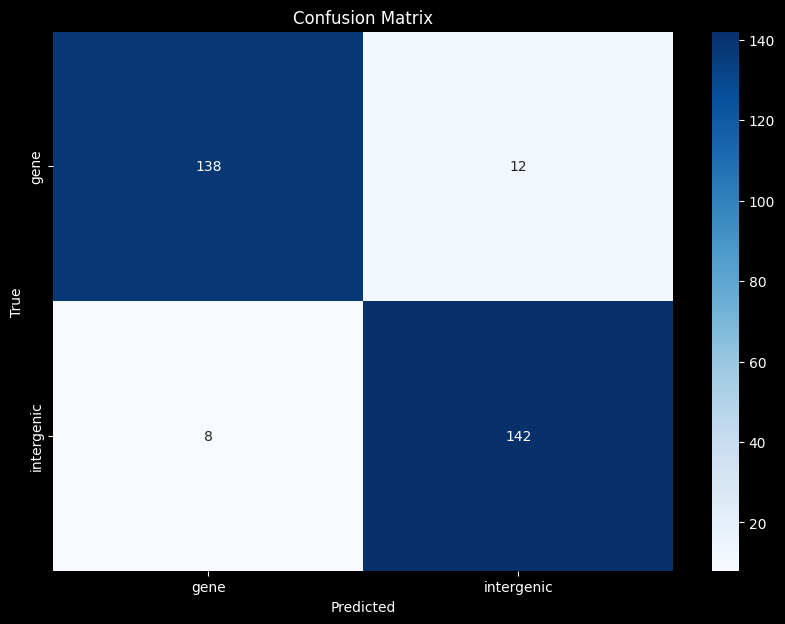

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Convert tensors to numpy arrays
pred_np = pred.cpu().numpy()
target_np = target.cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(target_np, pred_np)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['gene', 'intergenic'], yticklabels=['gene', 'intergenic'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()